<a href="https://colab.research.google.com/github/thomaslu678/Praxis-Lab-25-26/blob/main/clean/14_VIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTE: Requires calculations_df

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta
import scipy.stats as stats
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Point
import requests
import random
import os
import math
import copy
import sys
import gc

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Generate patches for park #2

In [5]:
point_row_col_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/2_Clipped.csv')

In [6]:
point_row_col_df

,row_index,col_index,point_id
0,17,1,0
1,18,1,1
2,19,1,2
3,20,1,3
4,21,1,4
...,...,...,...
4623,11,208,4623
4624,12,208,4624
4625,13,208,4625
4626,14,208,4626


In [7]:
point_row_col_df['point_id'] = point_row_col_df['point_id'] + 1

In [8]:
point_row_col_df

,row_index,col_index,point_id
0,17,1,1
1,18,1,2
2,19,1,3
3,20,1,4
4,21,1,5
...,...,...,...
4623,11,208,4624
4624,12,208,4625
4625,13,208,4626
4626,14,208,4627


In [9]:
lookup = {(r,c):pid for r,c,pid in zip(point_row_col_df.row_index, point_row_col_df.col_index, point_row_col_df.point_id)}

In [10]:
# Expect size to be an odd integer
def get_patches(df, size):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [11]:
PATCH_SIZE = 5

In [12]:
patches_2 = get_patches(point_row_col_df, PATCH_SIZE)
print(patches_2.shape)  # (#patches,5,5)

(3587, 5, 5)


# Generate patches for park #0 (Green Loop)

In [ ]:
point_row_col_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_Clipped.csv')

In [ ]:
point_row_col_df

,row_index,col_index,point_id
0,92,1,0
1,93,1,1
2,94,1,2
3,95,1,3
4,96,1,4
...,...,...,...
6936,23,72,6936
6937,24,72,6937
6938,25,72,6938
6939,26,72,6939


In [ ]:
lookup = {(r,c):pid for r,c,pid in zip(point_row_col_df.row_index, point_row_col_df.col_index, point_row_col_df.point_id)}

In [ ]:
# Expect size to be an odd integer
def get_patches(df, size):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [ ]:
PATCH_SIZE = 5

In [ ]:
patches_0 = get_patches(point_row_col_df, PATCH_SIZE)
print(patches_0.shape)  # (#patches,5,5)

(5629, 5, 5)


# Load datasets to populate patches

In [13]:
train_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/landsat_city_points_minimal.csv')

In [14]:
train_df = train_df_load.copy()

In [15]:
train_df['time'] = pd.to_datetime(train_df['time'], format='%Y-%m-%d %H:%M:%S')

In [16]:
train_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,2505,L4,1988-12-24 01:43:00,0.195835,0.210300,0.213737,0.196330,0.176255,272.622947
1,2527,L4,1988-12-24 01:43:00,0.202545,0.210300,0.213737,0.172900,0.148782,272.622947
2,2528,L4,1988-12-24 01:43:00,0.202545,0.204415,0.199850,0.163550,0.135087,272.622947
3,2550,L4,1988-12-24 01:43:00,0.195835,0.204415,0.192865,0.168225,0.141935,272.718652
4,2551,L4,1988-12-24 01:43:00,0.195835,0.210300,0.213737,0.177575,0.148782,272.718652
...,...,...,...,...,...,...,...,...,...
2646549,4618,L9,2026-01-31 02:11:17,0.065045,0.089052,0.131595,0.151615,0.115177,274.547293
2646550,4619,L9,2026-01-31 02:11:17,0.069005,0.108495,0.204250,0.236617,0.178015,274.506276
2646551,4620,L9,2026-01-31 02:11:17,0.117405,0.163055,0.224133,0.170673,0.129010,274.725030
2646552,4627,L9,2026-01-31 02:11:17,0.060067,0.080857,0.111052,0.118175,0.096917,274.588309


In [ ]:
predict_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_landsat.csv')

In [ ]:
predict_df = predict_df_load.copy()

In [ ]:
predict_df['time'] = pd.to_datetime(predict_df['time'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
predict_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,240,L4,1982-11-19 17:36:28,0.111658,0.120347,0.110805,0.079702,0.056575,280.665548
1,288,L4,1982-11-19 17:36:28,0.174220,0.207632,0.206780,0.206697,0.182030,281.209014
2,290,L4,1982-11-19 17:36:28,0.139927,0.167015,0.172570,0.156812,0.135830,280.665548
3,311,L4,1982-11-19 17:36:28,0.186622,0.224985,0.227268,0.197622,0.175430,280.665548
4,350,L4,1982-11-19 17:36:28,0.143062,0.178620,0.193112,0.143228,0.116002,281.752479
...,...,...,...,...,...,...,...,...,...
5628727,6936,L9,2026-01-12 18:08:31,0.024922,0.035647,0.052642,0.053825,0.038205,274.424244
5628728,6937,L9,2026-01-12 18:08:31,0.031055,0.047610,0.057125,0.040460,0.035290,275.466740
5628729,6938,L9,2026-01-12 18:08:31,0.039800,0.072580,0.071508,0.065155,0.058665,276.522908
5628730,6939,L9,2026-01-12 18:08:31,0.059682,0.104177,0.121502,0.164237,0.117130,277.271455


In [ ]:
print(predict_df['point_id'].min(), predict_df['point_id'].max())

0 6940


# Populate patches

In [18]:
features = ['Blue', 'Red', 'NIR', 'SWIR1', 'SWIR2']
target_col = 'LST_K'

In [19]:
def populate_patches(input_df, input_patches):

    # -------------------------
    # 1. Pivot
    # -------------------------
    df_pivot = input_df.pivot(
        index='time',
        columns='point_id',
        values=features + [target_col]
    ).sort_index()

    times = df_pivot.index.values
    point_ids = df_pivot.columns.levels[1].values

    # -------------------------
    # 2. Build feature tensor CORRECTLY
    # -------------------------
    # stack each feature explicitly to preserve alignment
    X = np.stack(
        [df_pivot[feat].values for feat in features],
        axis=-1
    )
    # shape: (T, P, F)

    y = df_pivot[target_col].values  # (T, P)

    # -------------------------
    # 3. point_id → index
    # -------------------------
    point_id_to_idx = {pid: i for i, pid in enumerate(point_ids)}

    all_patches_cubes = []
    all_patches_targets = []
    all_patches_times = []

    for patch in input_patches:
        patch = np.array(patch)
        flat_ids = patch.flatten()

        # map indices safely
        if not all(pid in point_id_to_idx for pid in flat_ids):
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        idxs = np.array([point_id_to_idx[pid] for pid in flat_ids])
        center_idx = point_id_to_idx[patch[2, 2]]

        # extract all times at once
        patch_data = X[:, idxs, :]   # (T, 25, F)

        # validity mask
        valid_mask = ~np.isnan(patch_data).any(axis=(1, 2))

        if not valid_mask.any():
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        valid_patch_data = patch_data[valid_mask]
        valid_targets = y[valid_mask, center_idx]
        valid_times = times[valid_mask]

        # reshape to cubes
        cubes = valid_patch_data.reshape(-1, 5, 5, len(features))
        cubes = np.transpose(cubes, (0, 3, 1, 2))  # (Tv, F, 5, 5)

        all_patches_cubes.append(cubes)
        all_patches_targets.append(valid_targets)
        all_patches_times.append(valid_times)

    return all_patches_cubes, all_patches_targets, all_patches_times

### Populate #0 patches

In [20]:
cubes_0, targets_0, times_0 = populate_patches(predict_df, patches_0)

NameError: name 'predict_df' is not defined

In [ ]:
cubes_0[0][0]

In [ ]:
targets_0[0][0]

In [ ]:
times_0[0][0]

In [ ]:
min_len = min(len(patch) for patch in times_0)
print(min_len)

### Populate #2 patches

In [21]:
cubes_2, targets_2, times_2 = populate_patches(train_df, patches_2)

In [22]:
cubes_2[0][0]

array([[[0.0883925, 0.0883925, 0.0900425, 0.091665 , 0.0867425],
        [0.0883925, 0.07357  , 0.08347  , 0.090015 , 0.0817925],
        [0.0834425, 0.0685925, 0.0817925, 0.0998325, 0.0801425],
        [0.0834425, 0.073515 , 0.071865 , 0.0866875, 0.08831  ],
        [0.076815 , 0.0652375, 0.0685375, 0.0833875, 0.098155 ]],

       [[0.1314025, 0.12824  , 0.13451  , 0.13451  , 0.12824  ],
        [0.1251325, 0.103215 , 0.1188625, 0.1314025, 0.1219975],
        [0.12824  , 0.096945 , 0.1157275, 0.1407525, 0.1251325],
        [0.1251325, 0.10635  , 0.103215 , 0.12824  , 0.1219975],
        [0.103215 , 0.0780525, 0.09062  , 0.1188625, 0.14386  ]],

       [[0.158875 , 0.158875 , 0.162725 , 0.162725 , 0.158875 ],
        [0.1549975, 0.1318425, 0.1511475, 0.158875 , 0.1511475],
        [0.158875 , 0.116415 , 0.1395975, 0.174275 , 0.1549975],
        [0.155025 , 0.1279925, 0.1318425, 0.158875 , 0.1549975],
        [0.1434475, 0.13572  , 0.13572  , 0.1511475, 0.178125 ]],

       [[0.14287  ,

In [23]:
targets_2[0][0]

np.float64(317.65877888)

In [24]:
times_2[0][0]

np.datetime64('1984-07-30T01:40:17.000000000')

In [25]:
min_len = min(len(patch) for patch in times_2)
print(min_len)

321


In [26]:
len(cubes_0)

NameError: name 'cubes_0' is not defined

# Compute time embeddings

In [31]:
def transform_times(transformed, times_0):
    for lst in times_0:
        new_lst = []
        # if not lst:
        #     transformed.append(new_lst)
        #     continue

        # Convert entire list at once (much faster)
        t = pd.to_datetime(lst)

        # Extract components (vectorized)
        year = t.year.values
        month = t.month.values
        day_of_year = t.dayofyear.values

        # Seasonality (vectorized)
        seasonality = np.sin((2 * np.pi) * day_of_year / 365)

        # Differences
        diff_prev = np.diff(t.values).astype('timedelta64[D]').astype(int)
        diff_prev = np.insert(diff_prev, 0, 0)  # first element = 0

        diff_first = (t - t[0]).days.values

        # Stack into feature matrix
        features = np.column_stack([
            year,
            month,
            day_of_year,
            seasonality,
            diff_prev,
            diff_first
        ])

        transformed.append(features.tolist())

## Time embeddings of 0

In [ ]:
time_embeddings_0 = []

In [ ]:
transform_times(time_embeddings_0, times_0)

In [ ]:
len(time_embeddings_0)

5629

## Time embeddings of 2

In [32]:
time_embeddings_2 = []

In [33]:
transform_times(time_embeddings_2, times_2)

In [34]:
len(time_embeddings_2)

3587

# Clip instead of sliding window

In [35]:
print(len(cubes_2), len(targets_2), len(time_embeddings_2))

3587 3587 3587


In [37]:
lengths = [len(item) for item in cubes_2]
min_len = min(lengths)
max_len = max(lengths)
print(min_len, max_len)

321 539


In [39]:
WINDOW = 300
num_samples = len(cubes_2)

In [42]:
E = len(time_embeddings_2[0][0])  # embedding size
print(E)

6


In [43]:
F = len(features)
print(F)

5


In [44]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, 5, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [49]:
sample_idx = 0
for seq_idx in range(len(cubes_2)):

    cubes_seq   = np.asarray(cubes_2[seq_idx], dtype=np.float32)   # (T,5,5,5)
    emb_seq     = np.asarray(time_embeddings_2[seq_idx], dtype=np.float32)  # (T,E)
    targets_seq = np.asarray(targets_2[seq_idx], dtype=np.float32)

    T_seq = cubes_seq.shape[0]

    if T_seq < WINDOW:
        continue

    # --- take ONLY the last window ---
    cube_window = cubes_seq[-WINDOW:]   # (W, 5, 5, 5)
    emb_window  = emb_seq[-WINDOW:]     # (W, E)

    # add batch dimension (since memmap expects batches)
    cube_window = cube_window[np.newaxis, ...]  # (1, W, 5,5,5)
    emb_window  = emb_window[np.newaxis, ...]   # (1, W, E)

    # target aligned to final window
    target = targets_seq[-1]  # scalar
    target = np.array([target], dtype=np.float32)  # (1,)

    # --- write 1 sample ---
    X_cubes[sample_idx] = cube_window[0]
    X_embs[sample_idx]  = emb_window[0]
    y[sample_idx]       = target[0]

    sample_idx += 1

    if (seq_idx % 100 == 0):
        print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

    X_cubes.flush()
    X_embs.flush()
    y.flush()

Finished 0, +1 sample (total 1)
Finished 100, +1 sample (total 101)
Finished 200, +1 sample (total 201)
Finished 300, +1 sample (total 301)
Finished 400, +1 sample (total 401)
Finished 500, +1 sample (total 501)
Finished 600, +1 sample (total 601)
Finished 700, +1 sample (total 701)
Finished 800, +1 sample (total 801)
Finished 900, +1 sample (total 901)
Finished 1000, +1 sample (total 1001)
Finished 1100, +1 sample (total 1101)
Finished 1200, +1 sample (total 1201)
Finished 1300, +1 sample (total 1301)
Finished 1400, +1 sample (total 1401)
Finished 1500, +1 sample (total 1501)
Finished 1600, +1 sample (total 1601)
Finished 1700, +1 sample (total 1701)
Finished 1800, +1 sample (total 1801)
Finished 1900, +1 sample (total 1901)
Finished 2000, +1 sample (total 2001)
Finished 2100, +1 sample (total 2101)
Finished 2200, +1 sample (total 2201)
Finished 2300, +1 sample (total 2301)
Finished 2400, +1 sample (total 2401)
Finished 2500, +1 sample (total 2501)
Finished 2600, +1 sample (total 2601

In [50]:
X_cubes.shape

(3587, 300, 5, 5, 5)

In [56]:
X_cubes[3586][0]

memmap([[[0.0613875, 0.0732125, 0.0672725, 0.0584175, 0.0406525],
         [0.0495625, 0.0584175, 0.0672725, 0.08204  , 0.055475 ],
         [0.0465925, 0.0436225, 0.0436225, 0.0643575, 0.0702425],
         [0.055475 , 0.052505 , 0.0436225, 0.0406525, 0.0465925],
         [0.0436225, 0.0495625, 0.052505 , 0.052505 , 0.0406525]],

        [[0.07632  , 0.0858625, 0.09062  , 0.09062  , 0.0476925],
         [0.06202  , 0.0715625, 0.09062  , 0.1048925, 0.07632  ],
         [0.0858625, 0.0667775, 0.0667775, 0.09062  , 0.100135 ],
         [0.095405 , 0.081105 , 0.06202  , 0.0476925, 0.057235 ],
         [0.057235 , 0.07632  , 0.1048925, 0.081105 , 0.0524775]],

        [[0.1158375, 0.131925 , 0.1372875, 0.1480125, 0.0783   ],
         [0.110475 , 0.1158375, 0.1480125, 0.1533475, 0.1694075],
         [0.19083  , 0.1640725, 0.1372875, 0.1372875, 0.1533475],
         [0.2015   , 0.2388725, 0.19083  , 0.1265625, 0.110475 ],
         [0.0729375, 0.1533475, 0.2388725, 0.233565 , 0.1694075]],

    

In [58]:
X_embs[3586][0]

memmap([ 2.006000e+03,  1.100000e+01,  3.200000e+02, -6.994583e-01,
         1.600000e+01,  8.144000e+03], dtype=float32)

In [59]:
y[3586]

np.float32(276.91257)

# Sliding window

## Calculate number of samples = length of each inner loop - 200 + 1

In [ ]:
targets_0[0][0]

np.float64(278.9018501)

In [ ]:
WINDOW = 300

In [ ]:
num_samples = 0
for time_series in cubes_0:
    num_samples += (len(time_series) - 200 + 1)

print(num_samples)

3095446


In [ ]:
E = len(time_embeddings_0[0][0])  # embedding size
print(E)

6


In [ ]:
F = len(features)
print(F)

5


In [ ]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, 5, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [ ]:
print(len(cubes_0))

5629


## Prepare main loop

In [ ]:
sample_idx = 0

In [ ]:
# ===== MAIN LOOP =====
for seq_idx in range(len(cubes_0)):

    # one-time conversion
    cubes_seq = np.asarray(cubes_0[seq_idx], dtype=np.float32)   # (T,5,5,5)
    emb_seq   = np.asarray(time_embeddings_0[seq_idx], dtype=np.float32)  # (T,E)
    targets_seq = np.asarray(targets_0[seq_idx], dtype=np.float32)

    T_seq = cubes_seq.shape[0]

    if T_seq <= WINDOW:
        continue

    # --- sliding windows ---
    cube_windows = sliding_window_view(cubes_seq, WINDOW, axis=0)
    emb_windows  = sliding_window_view(emb_seq, WINDOW, axis=0)

    # FIX: move WINDOW axis to position 1
    cube_windows = np.moveaxis(cube_windows, -1, 1)  # (N, W, 5, 5, 5)
    emb_windows  = np.moveaxis(emb_windows, -1, 1)   # (N, W, E)

    # align with target (drop last window)
    cube_windows = cube_windows[:-1]
    emb_windows  = emb_windows[:-1]

    # targets already aligned
    targets = targets_seq[WINDOW:]  # (N,)

    n = cube_windows.shape[0]

    # --- safety check (optional but recommended once) ---
    # assert cube_windows.shape == (n, WINDOW, 5, 5, 5)
    # assert emb_windows.shape == (n, WINDOW, E)
    # assert targets.shape == (n,)

    # --- bulk write ---
    X_cubes[sample_idx:sample_idx+n] = cube_windows
    X_embs[sample_idx:sample_idx+n]  = emb_windows
    y[sample_idx:sample_idx+n]       = targets

    sample_idx += n

    if (seq_idx % 100 == 0):
        print(f"Finished {seq_idx}, +{n} samples (total {sample_idx})")
        # flush once per 100
        X_cubes.flush()
        X_embs.flush()
        y.flush()

Finished 0, +494 samples (total 494)
Finished 100, +482 samples (total 49581)
Finished 200, +458 samples (total 96253)


KeyboardInterrupt: 

In [ ]:
X_cubes[100000][0][0][0][0]

np.float32(0.2404675)

In [ ]:
X_embs[450000][0]

memmap([ 2.003000e+03,  8.000000e+00,  2.130000e+02, -5.012418e-01,
         7.000000e+00,  7.056000e+03], dtype=float32)

In [ ]:
y[450000]

np.float32(307.77728)

In [ ]:
!ls -lh /content


total 15G
drwx------ 5 root root 4.0K Mar 30 07:03 drive
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data
-rw-r--r-- 1 root root 433G Mar 30 07:09 X_cubes.dat
-rw-r--r-- 1 root root  21G Mar 30 07:09 X_embs.dat
-rw-r--r-- 1 root root  12M Mar 30 07:09 y.dat


# Clean up RAM resources

In [ ]:
del cubes_0
del time_embeddings_0
del targets_0

In [ ]:
gc.collect()

0

In [ ]:
cubes_0

NameError: name 'cubes_0' is not defined

# Construct X and y datasets

In [60]:
NUM_SAMPLES = num_samples
WINDOW = 300

In [61]:
X_cubes_read = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES, WINDOW, 5, 5, 5)
)

X_embs_read = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES, WINDOW, E)
)

y_read = np.memmap(
    "y.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

In [80]:
# -----------------------------
# Config
# -----------------------------
CUBE_CHANNELS = 5
GRID_H = 5
GRID_W = 5
E = 6  # temporal encoding dimension

SUBSET_FRACTION = 0.01
TRAIN_FRACTION = 0.8

BATCH_SIZE = 8
NUM_EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 0
MAX_GRAD_NORM = 1.0
SEED = 1024
ACCUM_STEPS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "best_vit_regressor.pt"

In [81]:
# -----------------------------
# Reproducibility
# -----------------------------
def seed_everything(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

In [82]:
# -----------------------------
# Memmap Dataset
# -----------------------------
class MemmapSequenceDataset(Dataset):
    """
    Each item returns:
      x_cube: [T, C, H, W]   = [300, 5, 5, 5]
      x_emb:  [T, E]         = [300, 6]
      y:      scalar
    """

    def __init__(
        self,
        x_cubes_path,
        x_embs_path,
        y_path,
        indices,
        num_samples,
        window,
        emb_dim,
        cube_channels=5,
        grid_h=5,
        grid_w=5,
    ):
        self.x_cubes_path = x_cubes_path
        self.x_embs_path = x_embs_path
        self.y_path = y_path

        self.indices = np.asarray(indices, dtype=np.int64)
        self.num_samples = num_samples
        self.window = window
        self.emb_dim = emb_dim
        self.cube_channels = cube_channels
        self.grid_h = grid_h
        self.grid_w = grid_w

        self._x_cubes = None
        self._x_embs = None
        self._y = None

    def _lazy_open(self):
        if self._x_cubes is None:
            self._x_cubes = np.memmap(
                self.x_cubes_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.cube_channels, self.grid_h, self.grid_w),
            )
        if self._x_embs is None:
            self._x_embs = np.memmap(
                self.x_embs_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.emb_dim),
            )
        if self._y is None:
            self._y = np.memmap(
                self.y_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_open()

        sample_idx = int(self.indices[idx])

        # DO NOT copy unnecessarily
        x_cube = self._x_cubes[sample_idx]
        x_emb = self._x_embs[sample_idx]
        y = self._y[sample_idx]

        # Make writable safely (small cost, avoids warning)
        x_cube = np.array(x_cube, dtype=np.float32, copy=True)
        x_emb = np.array(x_emb, dtype=np.float32, copy=True)
        y = float(y)

        return (
            torch.from_numpy(x_cube),
            torch.from_numpy(x_emb),
            torch.tensor(y, dtype=torch.float32),
        )

In [83]:
# -----------------------------
# Model
# -----------------------------
class SpatialCubeEncoder(nn.Module):
    """
    Encodes each time step's cube independently.

    Input per sample:
      x_cube: [B, T, C, H, W]

    For each time step:
      - treat each of the 25 grid positions as a token
      - each token has 5 feature values
      - apply a Transformer encoder over those 25 tokens
      - return one vector per time step
    """

    def __init__(
        self,
        in_channels=5,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        grid_h=5,
        grid_w=5,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.num_tokens = grid_h * grid_w

        self.token_proj = nn.Linear(in_channels, d_model)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.spatial_pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d_model)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.spatial_pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.token_proj.weight)
        nn.init.zeros_(self.token_proj.bias)

    def forward(self, x_cube):
        """
        x_cube: [B, T, C, H, W]
        returns: [B, T, d_model]
        """
        B, T, C, H, W = x_cube.shape
        assert C == self.token_proj.in_features, f"Expected C={self.token_proj.in_features}, got {C}"
        assert H == self.grid_h and W == self.grid_w, f"Expected grid {self.grid_h}x{self.grid_w}, got {H}x{W}"

        # Treat each spatial cell as a token.
        # [B, T, C, H, W] -> [B*T, H*W, C]
        tokens = x_cube.permute(0, 1, 3, 4, 2).contiguous().view(B * T, H * W, C)
        tokens = self.token_proj(tokens)  # [B*T, 25, d_model]

        cls = self.cls_token.expand(B * T, -1, -1)  # [B*T, 1, d_model]
        tokens = torch.cat([cls, tokens], dim=1)    # [B*T, 26, d_model]
        tokens = tokens + self.spatial_pos_embed[:, : tokens.size(1), :]

        tokens = self.encoder(tokens)
        tokens = self.norm(tokens[:, 0])  # CLS token output, shape [B*T, d_model]

        return tokens.view(B, T, -1)


In [84]:
class TimeSeriesViTRegressor(nn.Module):
    """
    Hierarchical ViT-style model:
      1) spatial transformer over each 5x5 cube
      2) temporal transformer over the 300 timestamps
      3) regression head
    """

    def __init__(
        self,
        cube_channels=5,
        emb_dim=6,
        grid_h=5,
        grid_w=5,
        seq_len=300,
        d_model=128,
        spatial_heads=4,
        spatial_layers=1,
        temporal_heads=4,
        temporal_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.spatial_encoder = SpatialCubeEncoder(
            in_channels=cube_channels,
            d_model=d_model,
            nhead=spatial_heads,
            num_layers=spatial_layers,
            dropout=dropout,
            grid_h=grid_h,
            grid_w=grid_w,
        )

        self.temporal_proj = nn.Linear(emb_dim, d_model)

        self.temporal_cls = nn.Parameter(torch.zeros(1, 1, d_model))
        self.temporal_pos_embed = nn.Parameter(torch.zeros(1, seq_len + 1, d_model))

        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=temporal_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.temporal_cls, std=0.02)
        nn.init.trunc_normal_(self.temporal_pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.temporal_proj.weight)
        nn.init.zeros_(self.temporal_proj.bias)

        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x_cube, x_emb):
        """
        x_cube: [B, T, 5, 5, 5]
        x_emb:  [B, T, 6]
        returns: [B]
        """
        # Spatial encoding per timestamp
        spatial_repr = self.spatial_encoder(x_cube)  # [B, T, d_model]

        # Inject temporal encoding
        emb_repr = self.temporal_proj(x_emb)         # [B, T, d_model]
        x = spatial_repr + emb_repr

        # Temporal transformer
        B, T, D = x.shape
        cls = self.temporal_cls.expand(B, -1, -1)    # [B, 1, D]
        x = torch.cat([cls, x], dim=1)               # [B, T+1, D]
        x = x + self.temporal_pos_embed[:, : x.size(1), :]

        x = self.temporal_encoder(x)
        x = x[:, 0]                                  # CLS token

        out = self.head(x).squeeze(-1)               # [B]
        return out

In [89]:
# -----------------------------
# Train / Eval loops
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0

    for x_cube, x_emb, y in loader:
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            preds = model(x_cube, x_emb)
            loss = criterion(preds, y) / ACCUM_STEPS

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x_cube.size(0)
        print("batched finished")

    return running_loss / len(loader.dataset)

In [86]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for x_cube, x_emb, y in loader:
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        preds = model(x_cube, x_emb)
        loss = criterion(preds, y)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

In [87]:
# File paths
X_CUBES_PATH = "X_cubes.dat"
X_EMBS_PATH = "X_embs.dat"
Y_PATH = "y.dat"

# Build subset indices
subset_size = int(NUM_SAMPLES * SUBSET_FRACTION)
rng = np.random.default_rng(SEED)
selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
rng.shuffle(selected_indices)

# Train/val split
n_train = int(len(selected_indices) * TRAIN_FRACTION)
train_indices = selected_indices[:n_train]
val_indices = selected_indices[n_train:]

print("Train and val split done")

train_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=train_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
)

val_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=val_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

print("Datasets and loaders")

Train and val split done
Datasets and loaders


In [88]:
model = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0.1,
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

best_val_loss = float("inf")
best_state = None

print(f"Device: {DEVICE}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    print("Trained one epoch")
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    print("Evaluated")

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "config": {
                    "WINDOW": WINDOW,
                    "E": E,
                    "CUBE_CHANNELS": CUBE_CHANNELS,
                    "GRID_H": GRID_H,
                    "GRID_W": GRID_W,
                },
            },
            SAVE_PATH,
        )
        print(f"  Saved new best model to {SAVE_PATH}")

print(f"Best validation loss: {best_val_loss:.6f}")

# Optional: load best weights back into the model
# if best_state is not None:
#     model.load_state_dict(best_state)

/tmp/ipykernel_951/4055795266.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


Device: cpu
Train samples: 28
Val samples:   7
Epoch 001/10 | train_loss=20741.855190 | val_loss=78194.539062
  Saved new best model to best_vit_regressor.pt
Epoch 002/10 | train_loss=19968.445312 | val_loss=76573.070312
  Saved new best model to best_vit_regressor.pt
Epoch 003/10 | train_loss=19591.910156 | val_loss=75520.632812
  Saved new best model to best_vit_regressor.pt
Epoch 004/10 | train_loss=19378.684710 | val_loss=74779.679688
  Saved new best model to best_vit_regressor.pt
Epoch 005/10 | train_loss=19164.500558 | val_loss=74094.460938
  Saved new best model to best_vit_regressor.pt
Epoch 006/10 | train_loss=19026.179688 | val_loss=73420.515625
  Saved new best model to best_vit_regressor.pt
Epoch 007/10 | train_loss=18844.472377 | val_loss=72738.578125
  Saved new best model to best_vit_regressor.pt
Epoch 008/10 | train_loss=18693.143694 | val_loss=72037.085938
  Saved new best model to best_vit_regressor.pt
Epoch 009/10 | train_loss=18530.844029 | val_loss=71331.585938
  

In [90]:
model

TimeSeriesViTRegressor(
  (spatial_encoder): SpatialCubeEncoder(
    (token_proj): Linear(in_features=5, out_features=128, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (temporal_proj): Linear(in_features=6, out_features=128, 

# Load model in from .pt

In [ ]:
checkpoint = torch.load("/content/best_vit_regressor.pt", map_location=DEVICE, weights_only=True)

In [ ]:
cfg = checkpoint["config"]

model_recreate = TimeSeriesViTRegressor(
    cube_channels=cfg["CUBE_CHANNELS"],
    emb_dim=cfg["E"],
    grid_h=cfg["GRID_H"],
    grid_w=cfg["GRID_W"],
    seq_len=cfg["WINDOW"],
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0.1,
).to(DEVICE)

/tmp/ipykernel_15671/1847239167.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_15671/4055795266.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


In [ ]:
model_recreate.load_state_dict(checkpoint["model_state_dict"])
model_recreate.eval()

TimeSeriesViTRegressor(
  (spatial_encoder): SpatialCubeEncoder(
    (token_proj): Linear(in_features=5, out_features=128, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (temporal_proj): Linear(in_features=6, out_features=128, 

# Predict on validation dataset

In [91]:
batch_cubes, batch_embs, batch_y = next(iter(val_loader))

In [92]:
batch_y

tensor([291.1760, 289.9694, 292.0783, 281.1133, 289.9626, 290.3283, 274.8207])

In [94]:
batch_cubes.shape

torch.Size([7, 300, 5, 5, 5])

In [95]:
with torch.no_grad():
    # output = model_recreate(batch_cubes, batch_embs)
    output = model(batch_cubes, batch_embs)

In [96]:
print("Predictions:", output)
print("Targets:    ", batch_y)

Predictions: tensor([21.3819, 21.3824, 21.3824, 21.3816, 21.3824, 21.3823, 21.3818])
Targets:     tensor([291.1760, 289.9694, 292.0783, 281.1133, 289.9626, 290.3283, 274.8207])


# Shap Analysis

In [ ]:
# Sample sizes
BACKGROUND_SIZE = 200
EXPLAIN_SIZE = 500

# Sample indices from your train/val index arrays
background_sample_idx = np.random.choice(train_idx, BACKGROUND_SIZE, replace=False)
explain_sample_idx    = np.random.choice(val_idx, EXPLAIN_SIZE, replace=False)

# Function to load memmap samples and convert to torch (permute for ConvLSTM)
def load_memmap_batch(memmap_X, sample_indices, device):
    batch = memmap_X[sample_indices]  # shape: (B,T,H,W,C)
    batch = torch.tensor(batch, dtype=torch.float32, device=device)
    batch = batch.permute(0, 1, 4, 2, 3)  # (B,T,C,H,W)
    return batch

# Load SHAP background and explanation sets
X_background = load_memmap_batch(X, background_sample_idx, device)
X_explain    = load_memmap_batch(X, explain_sample_idx, device)

print(X_background.shape, X_explain.shape)

torch.Size([200, 50, 5, 5, 5]) torch.Size([500, 50, 5, 5, 5])


In [ ]:
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # original output: (B,)
        out = self.model(x)
        # add extra dimension: (B,) → (B,1)
        return out.unsqueeze(1)

In [ ]:
wrapped_model = ModelWrapper(model)
wrapped_model.eval()

ModelWrapper(
  (model): ConvLSTMModel(
    (cell): ConvLSTMCell(
      (conv): Conv2d(21, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (pool): AdaptiveAvgPool2d(output_size=(1, 1))
    (fc): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [ ]:
explainer = shap.DeepExplainer(wrapped_model, X_background)

AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 2.2678581564630784 - Tolerance: 0.01

In [ ]:
shap_values = explainer.shap_values(X_explain, check_additivity=False)

In [ ]:
X_background.shape

torch.Size([200, 50, 5, 5, 5])

In [ ]:
X_explain.shape

torch.Size([500, 50, 5, 5, 5])

In [ ]:
shap_values.shape

(500, 50, 5, 5, 5, 1)

In [ ]:
shap_vals = shap_values[..., 0]

In [ ]:
feature_importance = np.mean(np.abs(shap_vals), axis=(0,1,2,3))

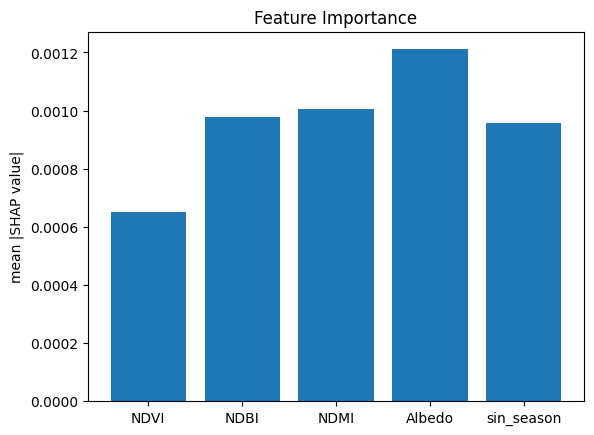

In [ ]:
feature_names = ["NDVI",	"NDBI",	"NDMI",	"Albedo",	"sin_season"]

plt.bar(feature_names, feature_importance)
plt.ylabel("mean |SHAP value|")
plt.title("Feature Importance")
plt.show()

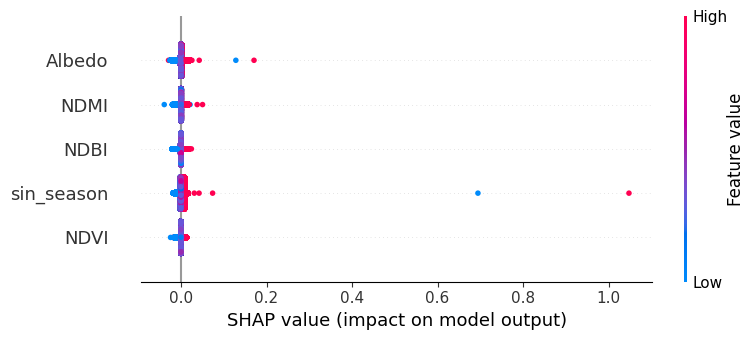

In [ ]:
X_flat = X_explain.reshape(-1, 5)
shap_flat = shap_vals.reshape(-1, 5)
shap.summary_plot(shap_flat, X_flat, feature_names=feature_names)

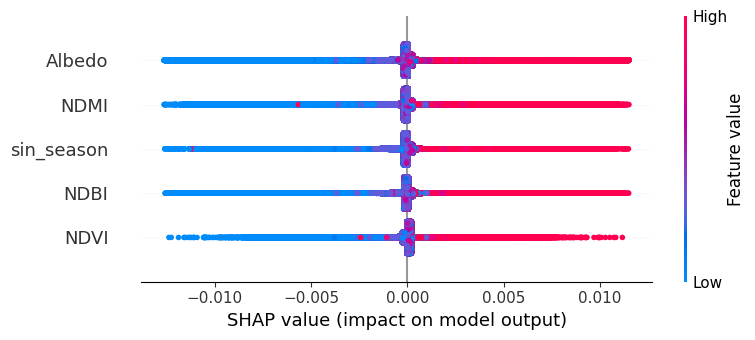

In [ ]:
low = np.percentile(shap_flat, 1)
high = np.percentile(shap_flat, 99)

mask = (shap_flat >= low) & (shap_flat <= high)

# keep rows where all features are within bounds
row_mask = mask.all(axis=1)

shap_filtered = shap_flat[row_mask]
X_filtered = X_flat[row_mask]

shap.summary_plot(shap_filtered, X_filtered, feature_names=feature_names)

## Save the model

In [ ]:
PATH = "/content/sample_data/MLP.pt"
torch.save(model.state_dict(), PATH)

In [ ]:
test_input = np.array([0.008107, -0.042450, 0.042450, 0.185196, 18.979367, 317.553292, 1, 12, -0.029627, 3.3725176e+00])

# single_input_scaled = scaler.transform(test_input.reshape(1, -1))  # Shape it to 2D for scaler
single_input_scaled = test_input.reshape(1, -1)  # Shape it to 2D for scaler
# single_input_scaled = scaler.transform(test_input.reshape(1, -1))  # Shape it to 2D for scaler
single_input_tensor = torch.tensor(single_input_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predicted_label = model(single_input_tensor).cpu().numpy()  # Convert the output to a NumPy array

print(f"Predicted label: {predicted_label}")

Predicted label: [[5.6785226]]


# Pull in Green Loop Data

In [ ]:
export_new_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_landsat.csv')

In [ ]:
export_new_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,240,L4,1982-11-19 17:36:28,0.111658,0.120347,0.110805,0.079702,0.056575,280.665548
1,288,L4,1982-11-19 17:36:28,0.174220,0.207632,0.206780,0.206697,0.182030,281.209014
2,290,L4,1982-11-19 17:36:28,0.139927,0.167015,0.172570,0.156812,0.135830,280.665548
3,311,L4,1982-11-19 17:36:28,0.186622,0.224985,0.227268,0.197622,0.175430,280.665548
4,350,L4,1982-11-19 17:36:28,0.143062,0.178620,0.193112,0.143228,0.116002,281.752479
...,...,...,...,...,...,...,...,...,...
5628727,6936,L9,2026-01-12 18:08:31,0.024922,0.035647,0.052642,0.053825,0.038205,274.424244
5628728,6937,L9,2026-01-12 18:08:31,0.031055,0.047610,0.057125,0.040460,0.035290,275.466740
5628729,6938,L9,2026-01-12 18:08:31,0.039800,0.072580,0.071508,0.065155,0.058665,276.522908
5628730,6939,L9,2026-01-12 18:08:31,0.059682,0.104177,0.121502,0.164237,0.117130,277.271455


In [ ]:
b = export_new_df['Blue']
r = export_new_df['Red']
nir = export_new_df['NIR']
swir1 = export_new_df['SWIR1']
swir2 = export_new_df['SWIR2']
lst_k = export_new_df['LST_K']

columns = ['point_id','time']
export_clean_df = export_new_df[columns]

export_clean_df['LST_C'] = lst_k - 273.15
export_clean_df['NDVI'] = (nir - r) / (nir + r)
export_clean_df['NDBI'] = (swir1 - nir) / (swir1 + nir)
export_clean_df['NDMI'] = (nir - swir1) / (nir + swir1)
export_clean_df['Albedo'] = ((0.356*b)+(0.130*r)+(0.373*nir)+(0.085*swir1)+(0.072*swir2)- 0.018)/ 1.016

/tmp/ipython-input-1499989114.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_clean_df['LST_C'] = lst_k - 273.15
/tmp/ipython-input-1499989114.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_clean_df['NDVI'] = (nir - r) / (nir + r)
/tmp/ipython-input-1499989114.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

In [ ]:
most_recent_mask = export_clean_df['time'] == "2026-01-12 18:08:31"
most_recent_data = export_clean_df[most_recent_mask]

In [ ]:
most_recent_data.columns

Index(['point_id', 'time', 'LST_C', 'NDVI', 'NDBI', 'NDMI', 'Albedo'], dtype='object')

In [ ]:
print(most_recent_data['NDVI'].max())   # want higher
print(most_recent_data['NDMI'].max())   # want higher
print(most_recent_data['Albedo'].max()) # want higher
print(most_recent_data['NDBI'].min())   # want lower

0.6431295217697915
0.615355734935234
0.5626349138779526
-0.615355734935234


In [ ]:
target_NDVI   = 0.6431295217697915
target_NDBI   = 0.615355734935234
target_NDMI   = 0.5626349138779526
target_Albedo = -0.615355734935234

In [ ]:
most_recent_data["NDVI_change"]   = target_NDVI   - most_recent_data["NDVI"]
most_recent_data["NDBI_change"]   = target_NDBI   - most_recent_data["NDBI"]
most_recent_data["NDMI_change"]   = target_NDMI   - most_recent_data["NDMI"]
most_recent_data["Albedo_change"] = target_Albedo - most_recent_data["Albedo"]

/tmp/ipython-input-2345914459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data["NDVI_change"]   = target_NDVI   - most_recent_data["NDVI"]
/tmp/ipython-input-2345914459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data["NDBI_change"]   = target_NDBI   - most_recent_data["NDBI"]
/tmp/ipython-input-2345914459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [ ]:
most_recent_data

,point_id,time,LST_C,NDVI,NDBI,NDMI,Albedo,NDVI_change,NDBI_change,NDMI_change,Albedo_change
5622170,0,2026-01-12 18:08:31,5.081918,0.332616,-0.065700,0.065700,0.069441,0.310514,0.681055,0.496935,-0.684797
5622171,1,2026-01-12 18:08:31,5.102426,0.327418,-0.132436,0.132436,0.096431,0.315711,0.747792,0.430199,-0.711787
5622172,2,2026-01-12 18:08:31,5.157115,0.378909,-0.164664,0.164664,0.077078,0.264220,0.780019,0.397971,-0.692434
5622173,3,2026-01-12 18:08:31,5.174205,0.404057,-0.101426,0.101426,0.100100,0.239072,0.716782,0.461209,-0.715456
5622174,4,2026-01-12 18:08:31,4.993050,0.315563,-0.027398,0.027398,0.117658,0.327566,0.642754,0.535237,-0.733014
...,...,...,...,...,...,...,...,...,...,...,...
5628727,6936,2026-01-12 18:08:31,1.274244,0.192491,0.011107,-0.011107,0.022114,0.450639,0.604249,0.573742,-0.637470
5628728,6937,2026-01-12 18:08:31,2.316740,0.090848,-0.170774,0.170774,0.026115,0.552281,0.786130,0.391861,-0.641470
5628729,6938,2026-01-12 18:08:31,3.372908,-0.007443,-0.046483,0.046483,0.041377,0.650573,0.661839,0.516152,-0.656732
5628730,6939,2026-01-12 18:08:31,4.121455,0.076768,0.149559,-0.149559,0.083173,0.566362,0.465797,0.712194,-0.698529


In [ ]:
ten_years_seconds = 315360000

In [ ]:
print(df['delta_time'].min())
print(df['delta_time'].max())
print(df['delta_time'].mean())

-756682739.0
1289089810.0
376003734.6639071


In [ ]:
most_recent_data['time_change'] = 315360000

/tmp/ipython-input-2792004285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data['time_change'] = 315360000


In [ ]:
most_recent_data.columns

Index(['point_id', 'time', 'LST_C', 'NDVI', 'NDBI', 'NDMI', 'Albedo',
       'NDVI_change', 'NDBI_change', 'NDMI_change', 'Albedo_change',
       'time_change'],
      dtype='object')

In [ ]:
columns_predict = ['point_id', 'time_change', 'NDVI_change', 'NDBI_change', 'NDMI_change', 'Albedo_change']
most_recent_predict = most_recent_data[columns_predict]

In [ ]:
most_recent_predict

,point_id,time_change,NDVI_change,NDBI_change,NDMI_change,Albedo_change
5622170,0,315360000,0.310514,0.681055,0.496935,-0.684797
5622171,1,315360000,0.315711,0.747792,0.430199,-0.711787
5622172,2,315360000,0.264220,0.780019,0.397971,-0.692434
5622173,3,315360000,0.239072,0.716782,0.461209,-0.715456
5622174,4,315360000,0.327566,0.642754,0.535237,-0.733014
...,...,...,...,...,...,...
5628727,6936,315360000,0.450639,0.604249,0.573742,-0.637470
5628728,6937,315360000,0.552281,0.786130,0.391861,-0.641470
5628729,6938,315360000,0.650573,0.661839,0.516152,-0.656732
5628730,6939,315360000,0.566362,0.465797,0.712194,-0.698529


In [ ]:
points_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_points.csv')

In [ ]:
points_df['point_id'] = points_df.index

In [ ]:
points_df

,long,lat,distance,point_id
0,-111.917514,40.750953,326.310297,0
1,-111.917512,40.750682,315.709676,1
2,-111.917511,40.750412,307.679686,2
3,-111.917509,40.750142,302.425162,3
4,-111.917507,40.749872,300.091933,4
...,...,...,...,...
6936,-111.892401,40.769679,207.667444,6936
6937,-111.892399,40.769409,237.666757,6937
6938,-111.892398,40.769139,267.666071,6938
6939,-111.892396,40.768869,297.665384,6939
